# Этап 4. Предобработка данных

**Цель этапа:** подготовить данные для обучения моделей машинного обучения.

**Шаги:**
1. Загрузка размеченного датасета
2. Кодирование текстовых признаков (One-Hot Encoding)
3. Разделение на три выборки: Train (60%) / Validation (20%) / Test (20%)
4. Масштабирование числовых признаков (StandardScaler) 

## 1. Загрузка данных

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle
import os

df = pd.read_csv('../data/russian_food_labeled.csv')

print('Размер датасета:', df.shape)
print()
print('Столбцы:', df.columns.tolist())
print()
print('Целевые переменные:')
targets = ['target_weightloss', 'target_gainmass', 'target_balance', 'target_sugar']
labels  = ['Похудение', 'Набор массы', 'Баланс/ЗОЖ', 'Контроль сахара']
for t, l in zip(targets, labels):
    n1 = df[t].sum()
    n0 = len(df) - n1
    print(f'  {l}: нужна замена={n1}, не нужна={n0}')

Размер датасета: (400, 14)

Столбцы: ['Food_Item', 'Category', 'Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Meal_Type', 'target_weightloss', 'target_gainmass', 'target_balance', 'target_sugar']

Целевые переменные:
  Похудение: нужна замена=218, не нужна=182
  Набор массы: нужна замена=206, не нужна=194
  Баланс/ЗОЖ: нужна замена=205, не нужна=195
  Контроль сахара: нужна замена=183, не нужна=217


## 2. Кодирование текстовых признаков (One-Hot Encoding)

Текстовые столбцы `Category` и `Meal_Type` нужно превратить в числовые.
**One-Hot Encoding** — каждое уникальное значение становится отдельным столбцом из 0 и 1.


In [16]:
# Применяем One-Hot Encoding к категориальным столбцам
df_encoded = pd.get_dummies(df, columns=['Category', 'Meal_Type'], drop_first=False)

# Убираем нечисловые и целевые столбцы для признаков
feature_cols = [c for c in df_encoded.columns
                if c not in ['Food_Item'] + targets
                and not c.startswith('target_')]

numeric_features = ['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)',
                     'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)']

print(f'Признаков до кодирования: {len(numeric_features)} (числовые)')
print(f'Признаков после кодирования: {len(feature_cols)}')
print()
print('Новые столбцы после One-Hot Encoding:')
new_cols = [c for c in feature_cols if 'Category_' in c or 'Meal_Type_' in c]
for c in new_cols:
    print(f'  {c}')

Признаков до кодирования: 7 (числовые)
Признаков после кодирования: 27

Новые столбцы после One-Hot Encoding:
  Category_Бобовые
  Category_Выпечка
  Category_Гарнир
  Category_Десерт
  Category_Европейское
  Category_Завтрак
  Category_Крупа
  Category_Молочное
  Category_Мясо
  Category_Напиток
  Category_Овощ
  Category_Орехи
  Category_Рыба
  Category_Салат
  Category_Суп
  Category_Фрукт
  Category_Яйца
  Meal_Type_Завтрак
  Meal_Type_Обед
  Meal_Type_Перекус


## 3. Разделение на три выборки

- **Train (60%)** — на этих данных модель обучается
- **Validation (20%)** — на этих данных подбираем гиперпараметры и сравниваем модели
- **Test (20%)** — финальная оценка, трогаем только один раз в самом конце

Используем **один общий split** для всех 4 целей (одни и те же строки в train/val/test,
различаются только столбцы `y`). Стратифицируем по `target_balance` — при проверке
это сочетание дало наименьший разброс баланса классов сразу по всем 4 целям.

In [17]:
X_all = df_encoded[feature_cols].copy()

# Единый split индексов — стратификация по target_balance (см. markdown выше)
idx_train, idx_test = train_test_split(
    df.index.values, test_size=0.2, random_state=42, stratify=df['target_balance']
)
idx_train, idx_val = train_test_split(
    idx_train, test_size=0.25, random_state=42, stratify=df.loc[idx_train, 'target_balance']
)

X_train = X_all.loc[idx_train].copy()
X_val   = X_all.loc[idx_val].copy()
X_test  = X_all.loc[idx_test].copy()

y_train = {label: df.loc[idx_train, t].values for label, t in zip(labels, targets)}
y_val   = {label: df.loc[idx_val,   t].values for label, t in zip(labels, targets)}
y_test  = {label: df.loc[idx_test,  t].values for label, t in zip(labels, targets)}

print('Размеры выборок:')
total = len(df)
print('  Train:     ', len(X_train), 'строк (', round(len(X_train)/total*100), '%)')
print('  Validation:', len(X_val),   'строк (', round(len(X_val)/total*100),   '%)')
print('  Test:      ', len(X_test),  'строк (', round(len(X_test)/total*100),  '%)')
print('  Итого:     ', len(X_train) + len(X_val) + len(X_test), 'строк')

Размеры выборок:
  Train:      240 строк ( 60 %)
  Validation: 80 строк ( 20 %)
  Test:       80 строк ( 20 %)
  Итого:      400 строк


## 4. Масштабирование числовых признаков (StandardScaler)

Числовые признаки имеют разные масштабы: калории (0–654 ккал), натрий (0–4800 мг), клетчатка (0–12.5 г).
Логистическая регрессия и kNN чувствительны к масштабу — признак с большими числами будет "перевешивать" остальные.

**Важно:** `scaler.fit()` вызываем **только на Train** — Validation и Test только `.transform()`.
Если обучить scaler на всех данных сразу (до split), информация о test-выборке "утечёт"
в среднее/стандартное отклонение, и оценка модели на test станет чуть более оптимистичной,
чем будет в реальности на новых данных.

In [18]:
scaler = StandardScaler()

# fit — только на train, transform — на всех трёх выборках
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val[numeric_features]   = scaler.transform(X_val[numeric_features])
X_test[numeric_features]  = scaler.transform(X_test[numeric_features])

print('Числовые признаки после масштабирования (Train):')
print(X_train[numeric_features].describe().round(2))

Числовые признаки после масштабирования (Train):
       Calories (kcal)  Protein (g)  Carbohydrates (g)  Fat (g)  Fiber (g)  \
count           240.00       240.00             240.00   240.00     240.00   
mean              0.00         0.00               0.00    -0.00      -0.00   
std               1.00         1.00               1.00     1.00       1.00   
min              -1.33        -1.12              -1.08    -0.76      -0.90   
25%              -0.79        -0.82              -0.72    -0.65      -0.66   
50%              -0.25        -0.30              -0.33    -0.40      -0.17   
75%               0.64         0.59               0.58     0.41       0.31   
max               4.19         3.06               3.72     6.25       5.19   

       Sugars (g)  Sodium (mg)  
count      240.00       240.00  
mean        -0.00        -0.00  
std          1.00         1.00  
min         -0.65        -1.07  
25%         -0.48        -0.86  
50%         -0.36        -0.50  
75%         -0.05

## 5. Проверка баланса классов в выборках

In [19]:
print('Баланс классов (доля "нужна замена = 1") по выборкам:')
print(f'{"Цель":<20} {"Train":>10} {"Val":>10} {"Test":>10}')
print('-' * 52)
for label in labels:
    train_pct = y_train[label].mean() * 100
    val_pct   = y_val[label].mean()   * 100
    test_pct  = y_test[label].mean()  * 100
    print(f'{label:<20} {train_pct:>9.1f}% {val_pct:>9.1f}% {test_pct:>9.1f}%')

Баланс классов (доля "нужна замена = 1") по выборкам:
Цель                      Train        Val       Test
----------------------------------------------------
Похудение                 52.9%      57.5%      56.2%
Набор массы               56.2%      41.2%      47.5%
Баланс/ЗОЖ                51.2%      51.2%      51.2%
Контроль сахара           48.8%      43.8%      38.8%


## 6. Визуализация разбиения

Раз split теперь один общий на все 4 цели — размер Train/Val/Test одинаков
для всех (60/20/20). Показываем это один раз, а баланс классов по целям — на
отдельном графике рядом.

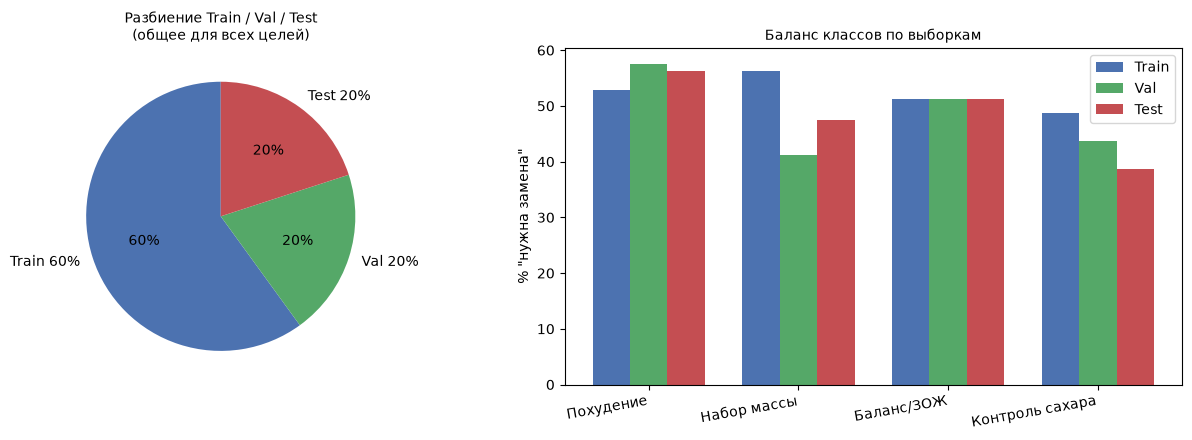

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Слева — размеры выборок (общие для всех целей)
sizes  = [len(X_train), len(X_val), len(X_test)]
colors = ['#4C72B0', '#55A868', '#C44E52']
names  = ['Train 60%', 'Val 20%', 'Test 20%']
axes[0].pie(sizes, labels=names, colors=colors, autopct='%1.0f%%', startangle=90)
axes[0].set_title('Разбиение Train / Val / Test\n(общее для всех целей)', fontsize=10)

# Справа — баланс классов по каждой цели и выборке
x = np.arange(len(labels))
width = 0.25
train_vals = [y_train[l].mean()*100 for l in labels]
val_vals   = [y_val[l].mean()*100   for l in labels]
test_vals  = [y_test[l].mean()*100  for l in labels]

axes[1].bar(x - width, train_vals, width, label='Train', color='#4C72B0')
axes[1].bar(x,         val_vals,   width, label='Val',   color='#55A868')
axes[1].bar(x + width, test_vals,  width, label='Test',  color='#C44E52')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=10, ha='right')
axes[1].set_ylabel('% "нужна замена"')
axes[1].set_title('Баланс классов по выборкам', fontsize=10)
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Сохранение результатов предобработки

In [21]:
# Сохраняем splits и scaler для использования в следующих этапах
os.makedirs('../data', exist_ok=True)

splits = {
    'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
    'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
}

with open('../data/splits.pkl', 'wb') as f:
    pickle.dump(splits, f)

with open('../data/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../data/feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print('Сохранено:')
print('  ../data/splits.pkl       — X_train/X_val/X_test + y_train/y_val/y_test (по 4 целям)')
print('  ../data/scaler.pkl       — обученный StandardScaler (fit только на train)')
print('  ../data/feature_cols.pkl — список признаков')

Сохранено:
  ../data/splits.pkl       — X_train/X_val/X_test + y_train/y_val/y_test (по 4 целям)
  ../data/scaler.pkl       — обученный StandardScaler (fit только на train)
  ../data/feature_cols.pkl — список признаков


## 8. Выводы по Этапу 4

1. Текстовые признаки `Category` (17 значений) и `Meal_Type` (3 значения) закодированы через One-Hot Encoding — итого получилось **27** признаков вместо исходных 7 числовых.
2. Данные разделены на три выборки: **Train 60% / Validation 20% / Test 20%**, один общий split для всех 4 целей (стратификация по `target_balance`), с фиксированным `random_state=42` для воспроизводимости.
3. Масштабирование (StandardScaler) выполнено **после** split и обучено **только на Train** — так избегаем утечки данных из test-выборки.
4. Баланс классов по всем 4 целям сохраняется в пределах ~1-6 п.п. между Train/Val/Test — приемлемо для такого небольшого датасета.
5. Все результаты сохранены в `.pkl` файлы для использования на этапе обучения моделей (этап 5).